<a href="https://colab.research.google.com/github/matteobosco0203/astrostatistics_bicocca_2026/blob/main/L22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
!pip install tensorflow

In [62]:
import tensorflow

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [64]:
data=pd.read_csv("galaxyquasar.csv", sep=",")

In [65]:
u_g=data['u']-data['g']
g_r=data['g']-data['r']
r_i=data['r']-data['i']
i_z=data['i']-data['z']
z=data['z1']

In [66]:
y=np.zeros(len(data['class']))
y[data['class']=='QSO']=1

from sklearn.model_selection import train_test_split

X=np.array([u_g,g_r,r_i,i_z])
X=X.transpose()
X_train_full, X_test = train_test_split(X, test_size=0.2, random_state=42)
y_train_full, y_test = train_test_split(y, test_size=0.2, random_state=42)



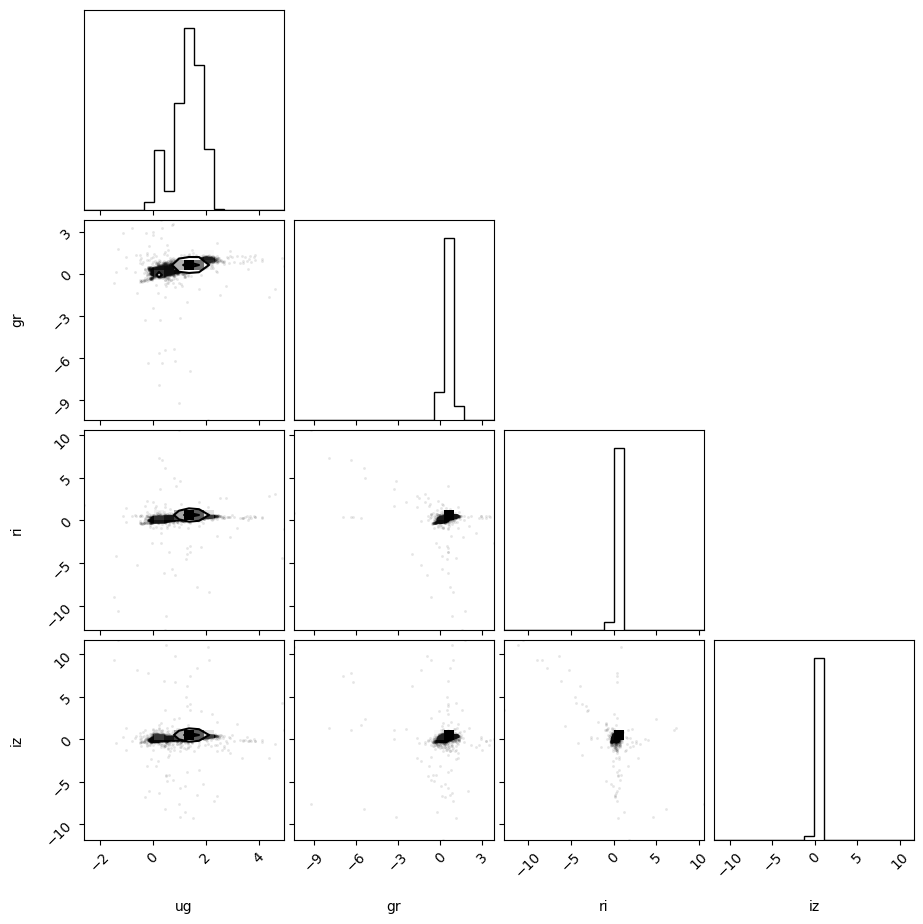

In [67]:
!pip install corner
import corner
corner.corner(X_train_full, labels=['ug', 'gr', 'ri', 'iz']);

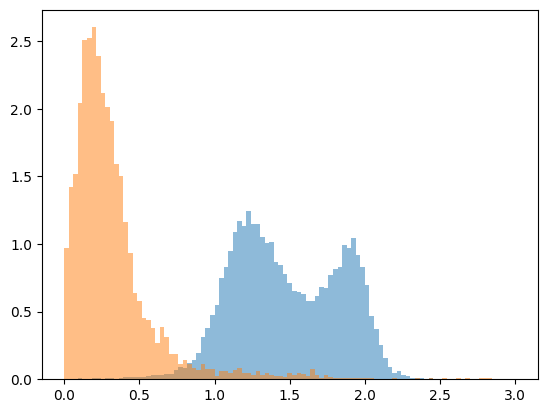

In [68]:
plt.hist(X_train_full[:,0][y_train_full==0], bins=np.linspace(0,3,100), density=True, alpha=0.5)
plt.hist(X_train_full[:,0][y_train_full==1], bins=np.linspace(0,3,100), density=True, alpha=0.5);

In [69]:
from tensorflow import keras

In [70]:
import tensorflow as tf

keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [71]:
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_train = X_train[:, :, np.newaxis]
X_valid = X_valid[:, :, np.newaxis]
X_test = X_test[:, :, np.newaxis]


In [72]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[4, 1]),
    keras.layers.Conv1D(filters=64, kernel_size=7, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=1),
    keras.layers.Conv1D(256, 3, activation='relu', padding='same'),
    keras.layers.Conv1D(256, 3, activation='relu', padding='same'),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [73]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 64)          │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 2, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 444,490 (1.70 MB)

 Trainable params: 444,490 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

None


In [74]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 47s 29ms/step - accuracy: 0.9742 - loss: 0.1191 - val_accuracy: 0.9860 - val_loss: 0.0572
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 28ms/step - accuracy: 0.9836 - loss: 0.0710 - val_accuracy: 0.9852 - val_loss: 0.0549
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.9837 - loss: 0.0673 - val_accuracy: 0.9860 - val_loss: 0.0533
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 28ms/step - accuracy: 0.9845 - loss: 0.0653 - val_accuracy: 0.9856 - val_loss: 0.0518
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - accuracy: 0.9846 - loss: 0.0625 - val_accuracy: 0.9858 - val_loss: 0.0505
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step - accuracy: 0.9854 - loss: 0.0614 - val_accuracy: 0.9862 - val_loss: 0.0506
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - accuracy: 0.9852 - loss: 0.0598 - val_accuracy: 0.9866 - val_loss: 0.0489
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9858 -

In [75]:
import sklearn
y_pred=np.argmax(model.predict(X_test), axis=-1)
print(sklearn.metrics.confusion_matrix(y_pred, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
[[8519   87]
 [  53 1341]]


In [76]:
!pip install astroML
from astroML.utils import completeness_contamination
completeness, contamination= completeness_contamination(y_pred,y_test)

In [77]:
X_new = X_test[:20]
y_proba = model.predict(X_new).round(4)
y_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


array([[9.922e-01, 7.800e-03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [9.960e-01, 4.000e-03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [1.400e-03, 9.986e-01, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [9.985e-01, 1.500e-03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [9.969e-01, 3.100e-03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [9.917e-01, 8.300e-03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [9.918e-01, 8.200e-03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [9.801e-01, 1.990e-02, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+

In [78]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_valid))))[:,1]
y_prob.shape

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


(5000,)

(0.9, 1.0)

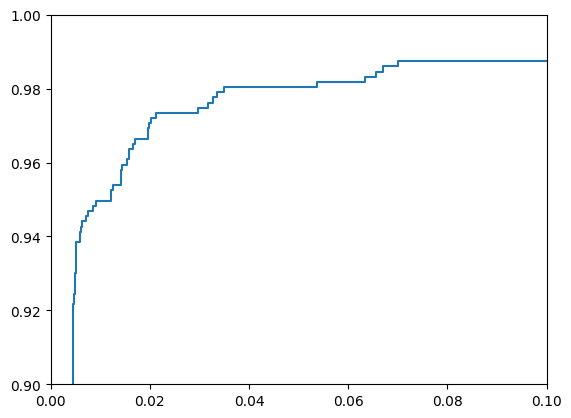

In [79]:
from sklearn.metrics import precision_recall_curve, roc_curve

fpr, tpr, thresh = roc_curve(y_valid, y_prob)
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)

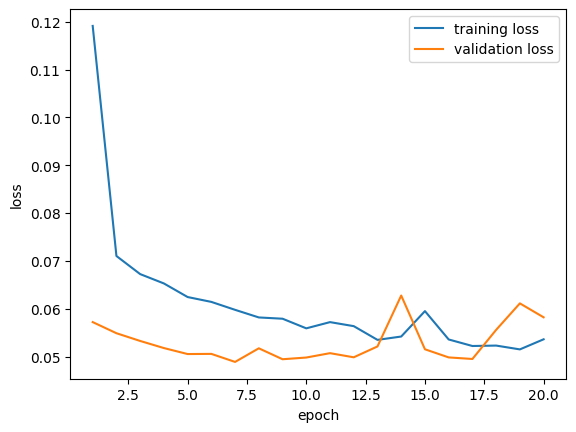

In [80]:
last_epoch = len(clf.history['loss'])
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['loss'], label='training loss')
plt.plot(epochs,clf.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')

plt.legend();

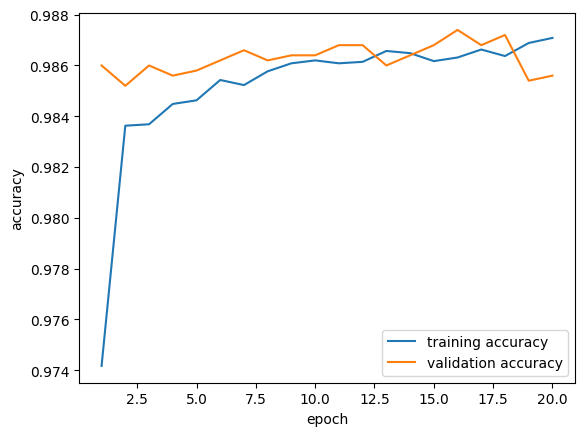

In [81]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['accuracy'], label='training accuracy')
plt.plot(epochs,clf.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')

plt.legend();